In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('csv_files/cleaned_data.csv')
df = df.dropna()
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (510, 10)

Column types:
place                 object
burglary_total         int64
median_income        float64
vacant_units           int64
owner_occupied         int64
renter_occupied        int64
median_home_value    float64
population             int64
burglary_rate        float64
high_risk              int64
dtype: object

First 5 rows:


,place,burglary_total,median_income,vacant_units,owner_occupied,renter_occupied,median_home_value,population,burglary_rate,high_risk
0,Addison,3,54519.0,19,160,82,132700.0,585,5.128205,1
1,Adrian,54,50209.0,1078,4414,3890,119900.0,20493,2.635046,1
2,Ahmeek,0,41250.0,55,49,4,75000.0,90,0.000000,0
3,Akron,1,50179.0,22,115,25,75500.0,312,3.205128,1
4,Alanson,0,65139.0,118,328,74,121200.0,943,0.000000,0


Burglary rate stats:
count    510.000000
mean       3.399346
std       19.561368
min        0.000000
25%        0.000000
50%        1.127401
75%        2.774936
max      405.903635
Name: burglary_rate, dtype: float64


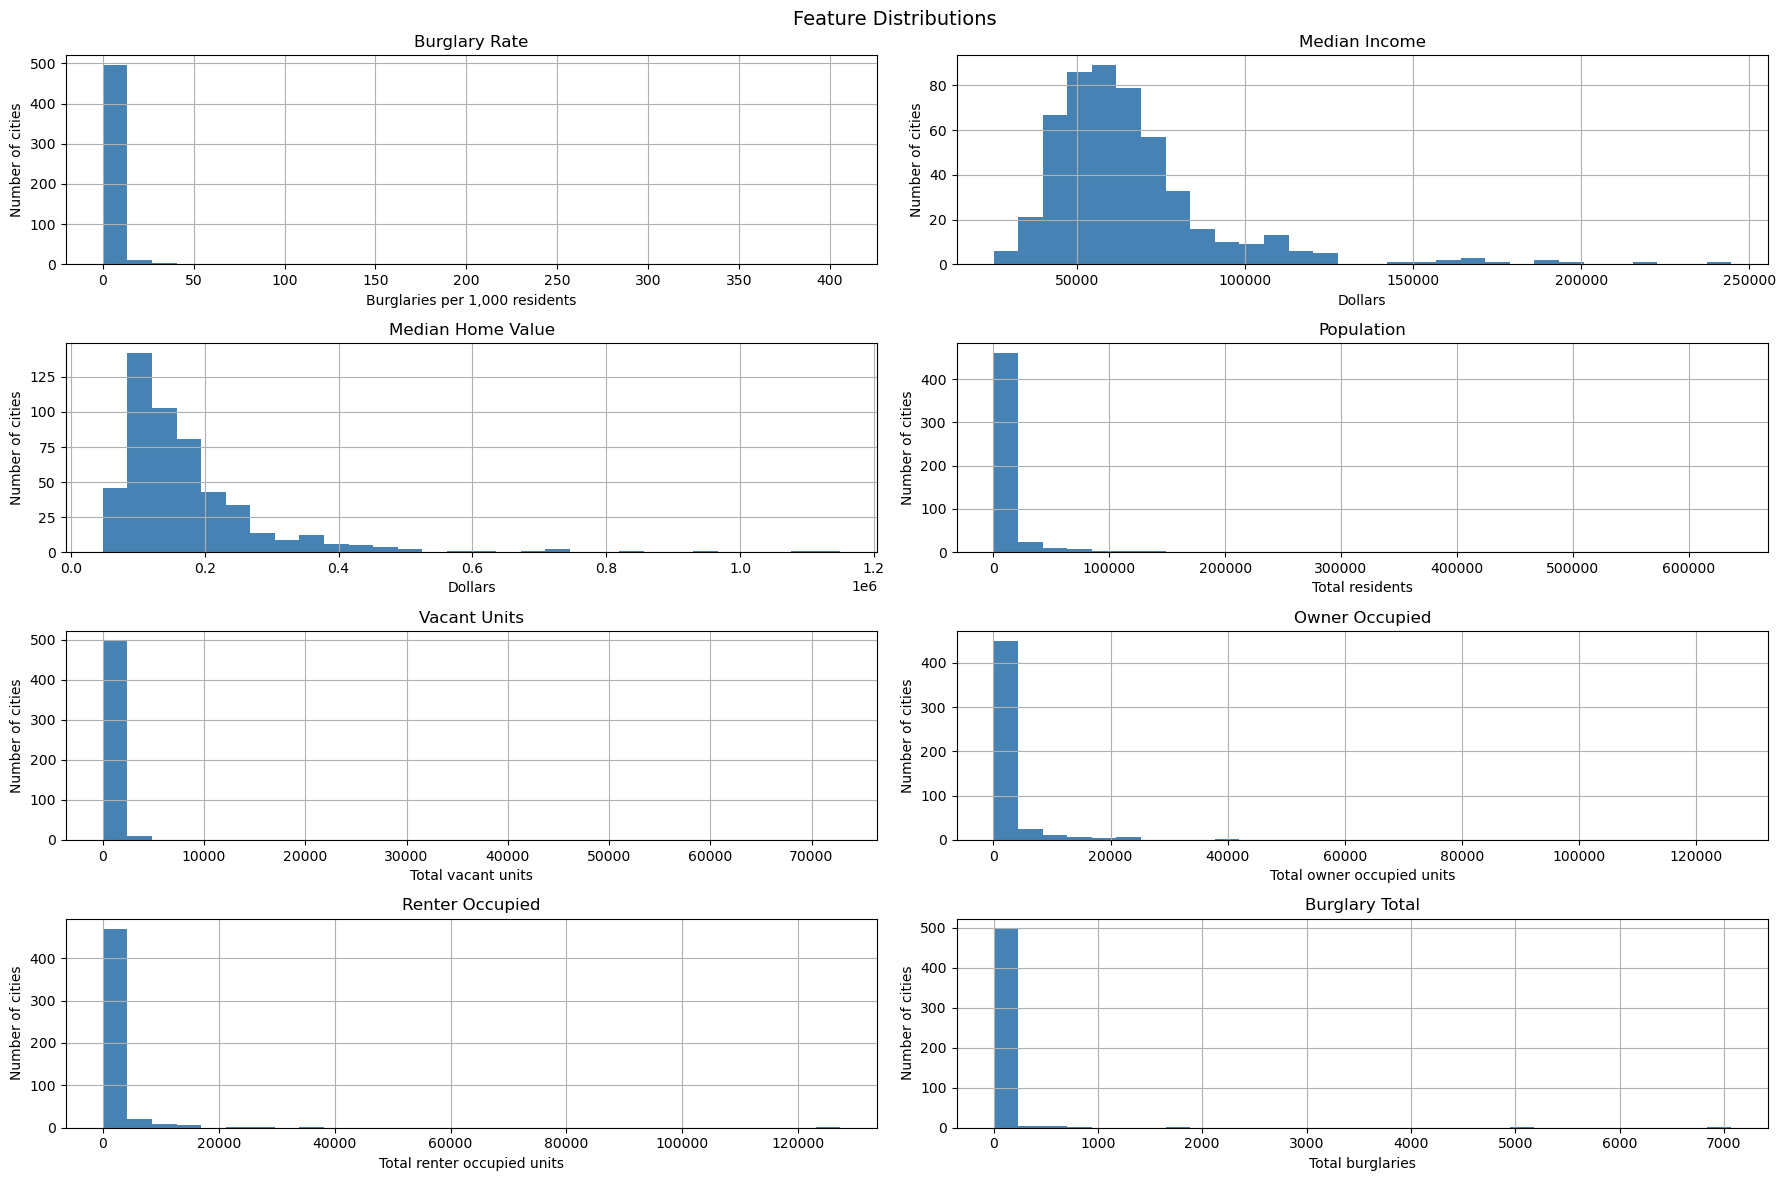

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(18, 12))

df['burglary_rate'].hist(ax=axes[0][0], bins=30, color='steelblue')
axes[0][0].set_title('Burglary Rate')
axes[0][0].set_xlabel('Burglaries per 1,000 residents')
axes[0][0].set_ylabel('Number of cities')

df['median_income'].hist(ax=axes[0][1], bins=30, color='steelblue')
axes[0][1].set_title('Median Income')
axes[0][1].set_xlabel('Dollars')
axes[0][1].set_ylabel('Number of cities')

df['median_home_value'].hist(ax=axes[1][0], bins=30, color='steelblue')
axes[1][0].set_title('Median Home Value')
axes[1][0].set_xlabel('Dollars')
axes[1][0].set_ylabel('Number of cities')

df['population'].hist(ax=axes[1][1], bins=30, color='steelblue')
axes[1][1].set_title('Population')
axes[1][1].set_xlabel('Total residents')
axes[1][1].set_ylabel('Number of cities')

df['vacant_units'].hist(ax=axes[2][0], bins=30, color='steelblue')
axes[2][0].set_title('Vacant Units')
axes[2][0].set_xlabel('Total vacant units')
axes[2][0].set_ylabel('Number of cities')

df['owner_occupied'].hist(ax=axes[2][1], bins=30, color='steelblue')
axes[2][1].set_title('Owner Occupied')
axes[2][1].set_xlabel('Total owner occupied units')
axes[2][1].set_ylabel('Number of cities')

df['renter_occupied'].hist(ax=axes[3][0], bins=30, color='steelblue')
axes[3][0].set_title('Renter Occupied')
axes[3][0].set_xlabel('Total renter occupied units')
axes[3][0].set_ylabel('Number of cities')

df['burglary_total'].hist(ax=axes[3][1], bins=30, color='steelblue')
axes[3][1].set_title('Burglary Total')
axes[3][1].set_xlabel('Total burglaries')
axes[3][1].set_ylabel('Number of cities')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
print("Burglary rate stats:")
print(df['burglary_rate'].describe())
plt.show()

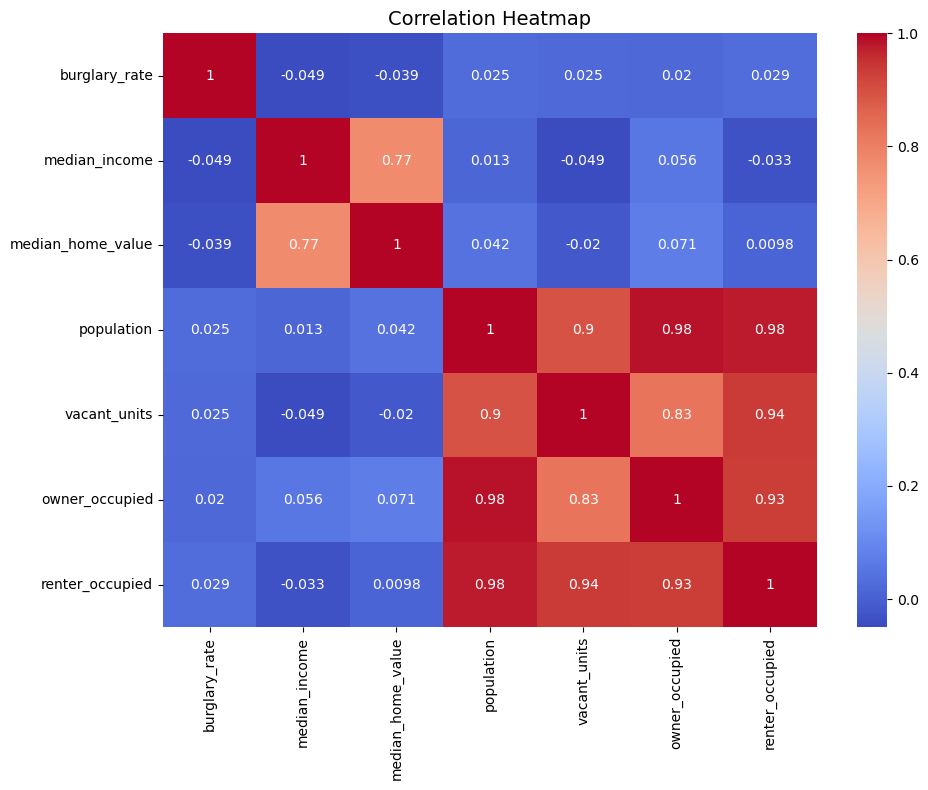

In [21]:
#Creating the Correlation Heatmap
cols = ['burglary_rate', 'median_income', 'median_home_value', 'population',
        'vacant_units', 'owner_occupied', 'renter_occupied']

correlation_matrix = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap = "coolwarm", annot = True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


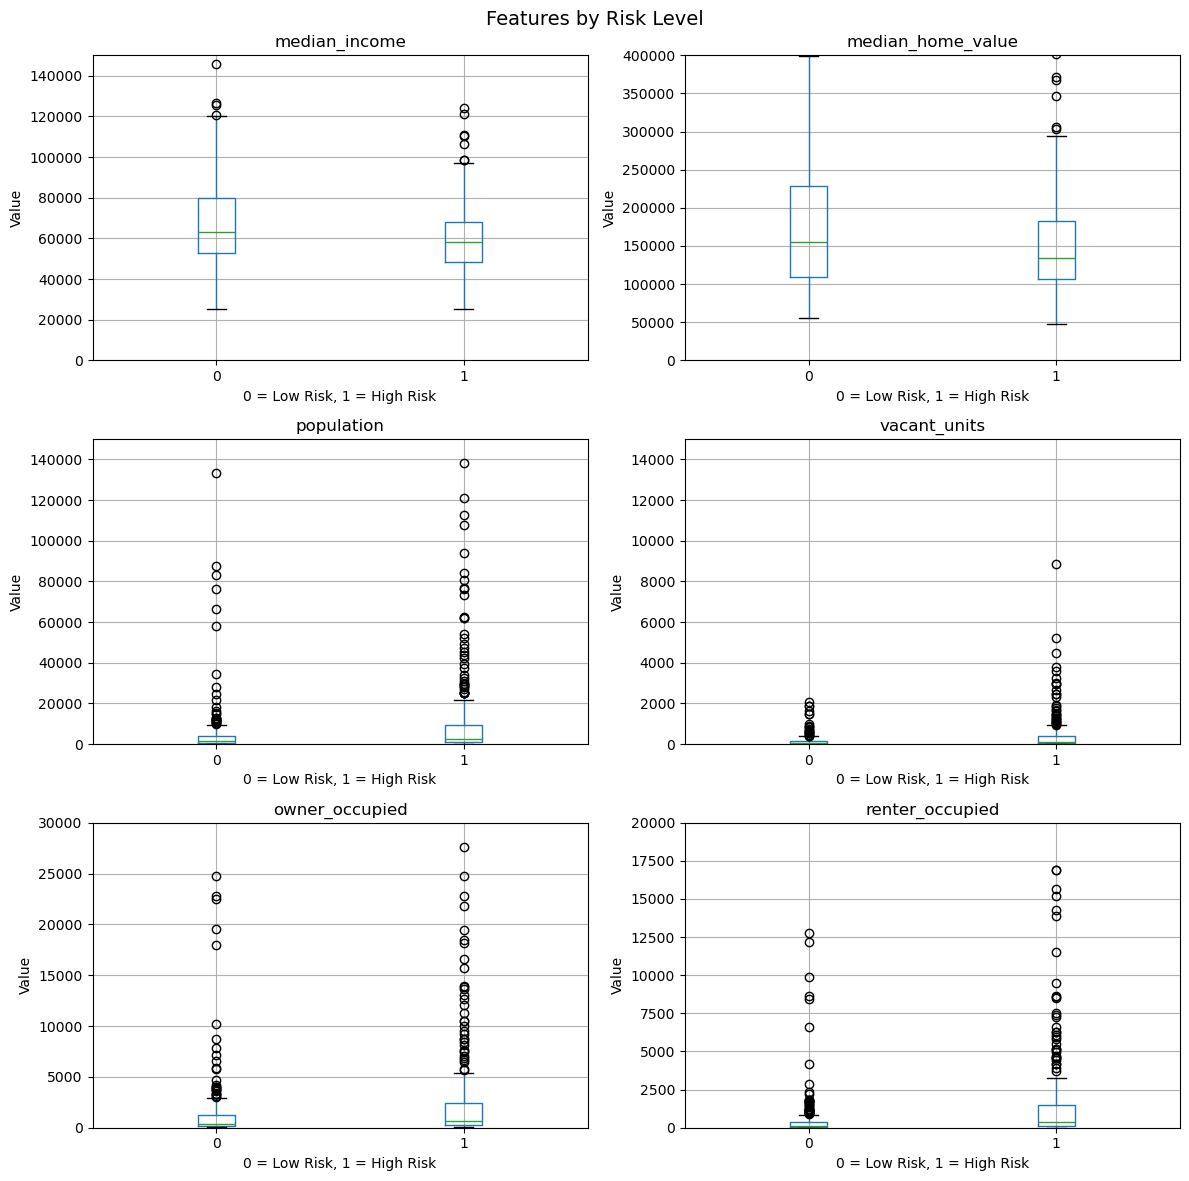

In [24]:
# Boxplots comparing high vs low risk cities for each feature
cols = ['median_income', 'median_home_value', 'population',
        'vacant_units', 'owner_occupied', 'renter_occupied']

ylims = [150000, 400000, 150000, 15000, 30000, 20000] #getting rid of extreme outliers

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    df.boxplot(column=col, by='high_risk', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('0 = Low Risk, 1 = High Risk')
    axes[i].set_ylabel('Value')
    axes[i].set_ylim(0, ylims[i])

plt.suptitle('Features by Risk Level', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
#Takeaways so far:
#Income and home value are the two most useful features going into modeling. 
#The housing size features (population, units) don't separate the classes well

In [25]:
# Top 10 most risky cities
print("Top 10 Most Risky Cities:")
print(df[['place', 'burglary_rate', 'high_risk']].nlargest(10, 'burglary_rate').to_string(index=False))

print()

# Top 10 least risky cities
print("Top 10 Least Risky Cities:")
print(df[['place', 'burglary_rate', 'high_risk']].nsmallest(10, 'burglary_rate').to_string(index=False))

Top 10 Most Risky Cities:
      place  burglary_rate  high_risk
      Wayne     405.903635          1
  Sand Lake     158.154860          1
  Roscommon      34.985423          1
    Clinton      33.273703          1
    Allegan      32.612891          1
  Kalamazoo      24.366898          1
Schoolcraft      22.082019          1
    Jackson      19.451388          1
    Newaygo      18.101368          1
    Saginaw      18.026847          1

Top 10 Least Risky Cities:
    place  burglary_rate  high_risk
   Ahmeek            0.0          0
  Alanson            0.0          0
Applegate            0.0          0
   Armada            0.0          0
   Ashley            0.0          0
  Augusta            0.0          0
 Bancroft            0.0          0
 Barryton            0.0          0
Bear Lake            0.0          0
 Bellaire            0.0          0


In [26]:
# Looking at Oakland County
oakland_cities = ['Pontiac', 'Troy', 'Royal Oak', 'Farmington Hills', 
                  'Southfield', 'Auburn Hills', 'Waterford', 'Clawson']

oakland = df[df['place'].isin(oakland_cities)]

print(oakland[['place', 'burglary_rate', 'high_risk']].sort_values('burglary_rate', ascending=False).to_string(index=False))

           place  burglary_rate  high_risk
         Pontiac       3.359499          1
      Southfield       2.985860          1
    Auburn Hills       1.806431          1
Farmington Hills       0.960200          0
            Troy       0.790315          0
       Royal Oak       0.587422          0
         Clawson       0.441930          0


In [ ]:
df.to_csv('csv_files/cleaned_data.csv', index=False)
"""
git add .
git commit -m "Week 2: EDA complete"
git push
"""